# 01 — Exploratory Data Analysis
## 307,511 Loan Applications, and What Separates the 8% Who Default

**Credit Scoring Capstone — Module 1**

The lending desk approves or declines consumer credit applications. Every approval is a bet that the applicant repays; the model we build in notebooks 02–05 prices that bet at underwriting time (Step 3 of the lending process). This notebook is the reconnaissance: what does the raw application data actually contain, where does it lie to us, and which of the **Five Cs of credit** — Character, Capacity, Capital, Collateral, Conditions — does it let us measure?

Two tables:

| Table | Rows | Grain | Five-Cs role |
|---|---|---|---|
| `application_train.csv` | 307,511 × 122 | one per application | Capacity, Capital, Collateral, Conditions |
| `bureau.csv` | 1,716,428 × 17 | one per *prior credit* at other lenders | **Character** — repayment history |

`TARGET = 1` means the client had payment difficulties (late > threshold days on at least one installment). This notebook answers five questions that shape everything downstream:

1. How rare is default, and what does that do to our metrics?
2. Where does the data lie? (sentinels, disguised missing values)
3. What is *actually* missing, and is missingness itself a signal?
4. Which features separate defaulters — and by how much?
5. What does the bureau history add?

In [1]:
import sys, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data, cleaning, features, plotting
from src.plotting import (BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET,
                          MUTED, INK_2, GRID, GOOD, CRITICAL, direct_label,
                          fmt_pct, subtitle, save_figure)

plotting.apply_style()
config.set_seed()

app_raw = data.load_application()
print(f"applications: {app_raw.shape[0]:,} rows x {app_raw.shape[1]} columns")

applications: 307,511 rows x 122 columns


---
## 1. The Target: Default Is Rare, and That Changes Everything

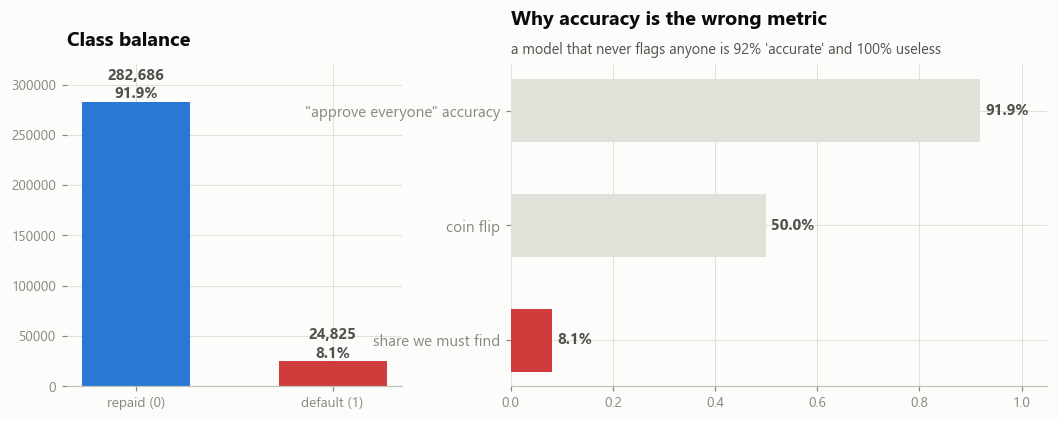

In [2]:
rate = app_raw["TARGET"].mean()
counts = app_raw["TARGET"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8), gridspec_kw={"width_ratios": [1, 1.6], "wspace": 0.25})
ax1.bar([0, 1], counts.values, color=[BLUE, CRITICAL], width=0.55)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["repaid (0)", "default (1)"])
for i, v in enumerate(counts.values):
    ax1.text(i, v + 4000, f"{v:,}\n{v/len(app_raw):.1%}", ha="center", fontsize=10,
             fontweight="bold", color=INK_2)
ax1.set_ylim(0, 320000)
ax1.set_title("Class balance")

# what accuracy would a useless model get?
ax2.barh([2, 1, 0], [1 - rate, 0.5, rate], color=[GRID, GRID, CRITICAL], height=0.55)
ax2.set_yticks([2, 1, 0])
ax2.set_yticklabels(['"approve everyone" accuracy', "coin flip", "share we must find"], fontsize=10)
for y, v in zip([2, 1, 0], [1 - rate, 0.5, rate]):
    ax2.text(v + 0.01, y, f"{v:.1%}", va="center", fontsize=10, fontweight="bold", color=INK_2)
ax2.set_xlim(0, 1.05)
ax2.set_title("Why accuracy is the wrong metric")
subtitle(ax2, "a model that never flags anyone is 92% 'accurate' and 100% useless")
save_figure(fig, "eda_class_balance")
plt.show()

**Consequences baked into the whole project:** evaluation uses **AUROC / Gini / KS** and the precision-recall trade-off, never raw accuracy; splits are **stratified** so every set has the same 8.07% default rate; and the business framing is asymmetric — a missed default costs ~13× more than a wrongly-declined good customer (loss given default vs foregone profit, quantified in notebook 04).

---
## 2. Where the Data Lies: the 1,000-Year Employee

`DAYS_EMPLOYED` should be a negative day-count (days employed before application). Its histogram says otherwise.

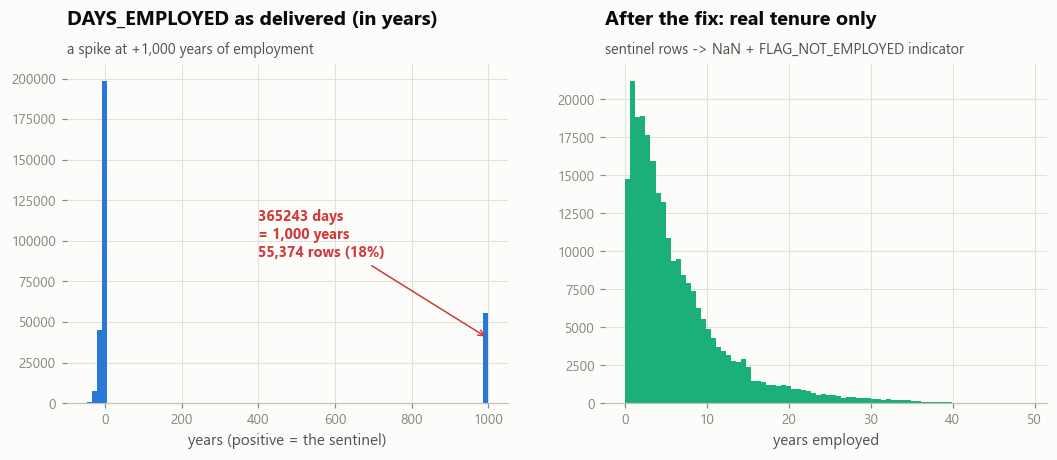

Income type of sentinel rows:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22

Default rate | sentinel rows:  5.40%
Default rate | everyone else:  8.66%


In [3]:
col = app_raw["DAYS_EMPLOYED"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4), gridspec_kw={"wspace": 0.22})
ax1.hist(col / 365.25, bins=80, color=BLUE, lw=0)
ax1.set_title("DAYS_EMPLOYED as delivered (in years)")
subtitle(ax1, "a spike at +1,000 years of employment")
ax1.set_xlabel("years (positive = the sentinel)")
ax1.annotate(f"365243 days\n= {cleaning.DAYS_EMPLOYED_SENTINEL/365.25:,.0f} years\n{int((col == cleaning.DAYS_EMPLOYED_SENTINEL).sum()):,} rows (18%)",
             xy=(1000, 40000), xytext=(400, 90000), fontsize=9.5, color=CRITICAL,
             fontweight="bold", arrowprops=dict(arrowstyle="->", color=CRITICAL))

fixed = cleaning.fix_sentinels(app_raw)
ax2.hist(-fixed["DAYS_EMPLOYED"].dropna() / 365.25, bins=80, color=AQUA, lw=0)
ax2.set_title("After the fix: real tenure only")
subtitle(ax2, "sentinel rows -> NaN + FLAG_NOT_EMPLOYED indicator")
ax2.set_xlabel("years employed")
save_figure(fig, "eda_sentinel")
plt.show()

# who are the sentinel rows? overwhelmingly pensioners
who = app_raw.loc[col == cleaning.DAYS_EMPLOYED_SENTINEL, "NAME_INCOME_TYPE"].value_counts()
print("Income type of sentinel rows:")
print(who.head(3).to_string())
sent_rate = app_raw.loc[col == cleaning.DAYS_EMPLOYED_SENTINEL, "TARGET"].mean()
print(f"\nDefault rate | sentinel rows:  {sent_rate:.2%}")
print(f"Default rate | everyone else:  {app_raw.loc[col != cleaning.DAYS_EMPLOYED_SENTINEL, 'TARGET'].mean():.2%}")

**The trap this avoids:** left as-is, the sentinel makes "employment length" the *most extreme value in the dataset* for 18% of applicants — a tree model would happily split on nonsense, and a linear model would be poisoned by a value 200× larger than any real tenure. The fix (NaN + indicator flag) keeps the true signal: these are almost all **pensioners**, who actually default *less* (5.4% vs 8.7%).

Other lies found and handled in `src/cleaning.py`: `CODE_GENDER = 'XNA'` (4 rows) and `ORGANIZATION_TYPE = 'XNA'` (the string, on 55k rows — the same pensioners).

---
## 3. Missingness: What Is Absent, and Is Absence Informative?

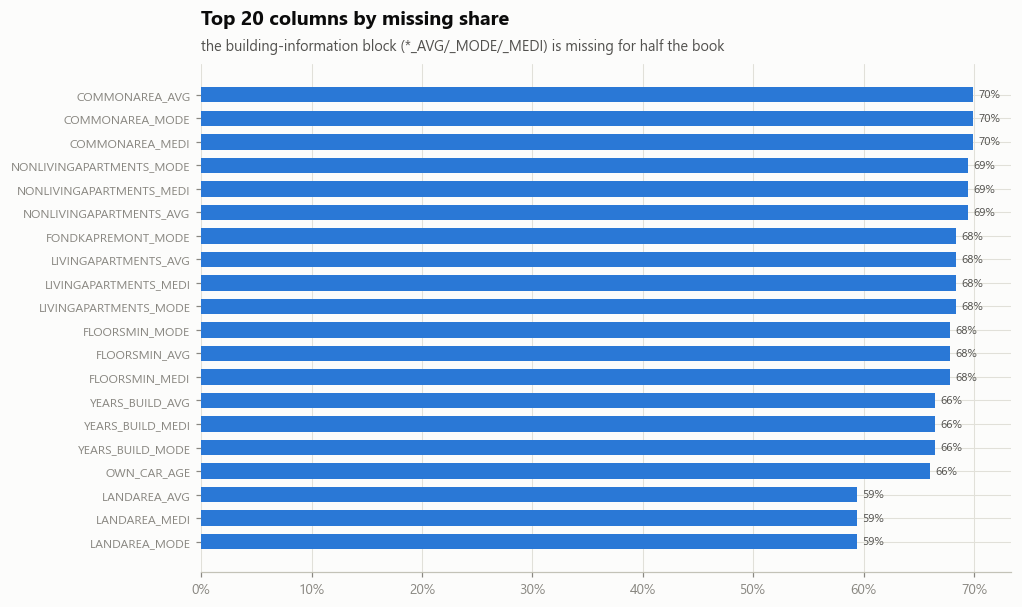

building-info columns: 47 of 126


In [4]:
app = cleaning.add_readable_units(fixed)
miss = cleaning.missing_summary(app, top=20)

fig, ax = plt.subplots(figsize=(9.5, 6))
vals = miss["missing_share"][::-1]
ax.barh(range(len(vals)), vals.values, color=BLUE, height=0.65)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(vals.index, fontsize=8)
ax.set_title("Top 20 columns by missing share")
subtitle(ax, "the building-information block (*_AVG/_MODE/_MEDI) is missing for half the book")
fmt_pct(ax, "x")
for i, v in enumerate(vals.values):
    ax.text(v + 0.005, i, f"{v:.0%}", va="center", fontsize=7.5, color=INK_2)
save_figure(fig, "eda_missingness")
plt.show()

n_building = sum(1 for c in app.columns if c.endswith(("_AVG", "_MODE", "_MEDI")))
print(f"building-info columns: {n_building} of {app.shape[1]}")

In [5]:
# Is missingness itself a signal? Compare default rates with/without key fields.
rows = []
for c in ["EXT_SOURCE_1", "EXT_SOURCE_3", "OWN_CAR_AGE", "OCCUPATION_TYPE"]:
    present = app.loc[app[c].notna(), "TARGET"].mean()
    absent = app.loc[app[c].isna(), "TARGET"].mean()
    rows.append({"feature": c, "missing_share": app[c].isna().mean(),
                 "default_rate_present": present, "default_rate_missing": absent,
                 "lift": absent / present})
pd.DataFrame(rows).round(3)

,feature,missing_share,default_rate_present,default_rate_missing,lift
0,EXT_SOURCE_1,0.564,0.075,0.085,1.137
1,EXT_SOURCE_3,0.198,0.078,0.093,1.199
2,OWN_CAR_AGE,0.660,0.072,0.085,1.173
3,OCCUPATION_TYPE,0.313,0.088,0.065,0.741


**Yes — absence is informative.** Applicants with no `EXT_SOURCE_1` (no long external credit record) default at a meaningfully higher rate than those who have one. So the preprocessing keeps *missingness indicators* rather than silently imputing the gaps away — imputation fills the hole, the flag remembers the hole existed.

---
## 4. Who Defaults? The Features That Separate the 8%

### The external scores — the strongest single predictors

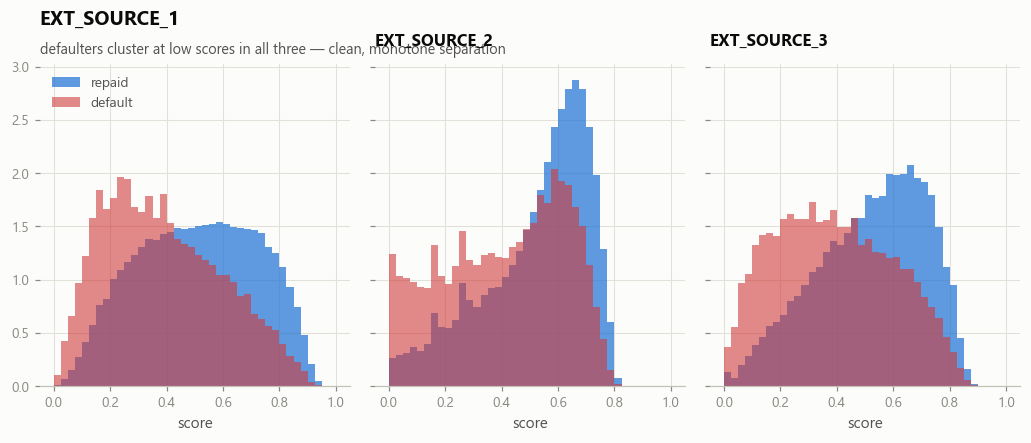

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True, gridspec_kw={"wspace": 0.08})
for ax, c in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    good = app.loc[app["TARGET"] == 0, c].dropna()
    bad = app.loc[app["TARGET"] == 1, c].dropna()
    bins = np.linspace(0, 1, 41)
    ax.hist(good, bins=bins, density=True, color=BLUE, alpha=0.75, lw=0, label="repaid")
    ax.hist(bad, bins=bins, density=True, color=CRITICAL, alpha=0.60, lw=0, label="default")
    ax.set_title(c, fontsize=11)
    ax.set_xlabel("score")
axes[0].legend(loc="upper left")
subtitle(axes[0], "defaulters cluster at low scores in all three \u2014 clean, monotone separation")
save_figure(fig, "eda_ext_sources")
plt.show()

### Age, capacity, and segment risk

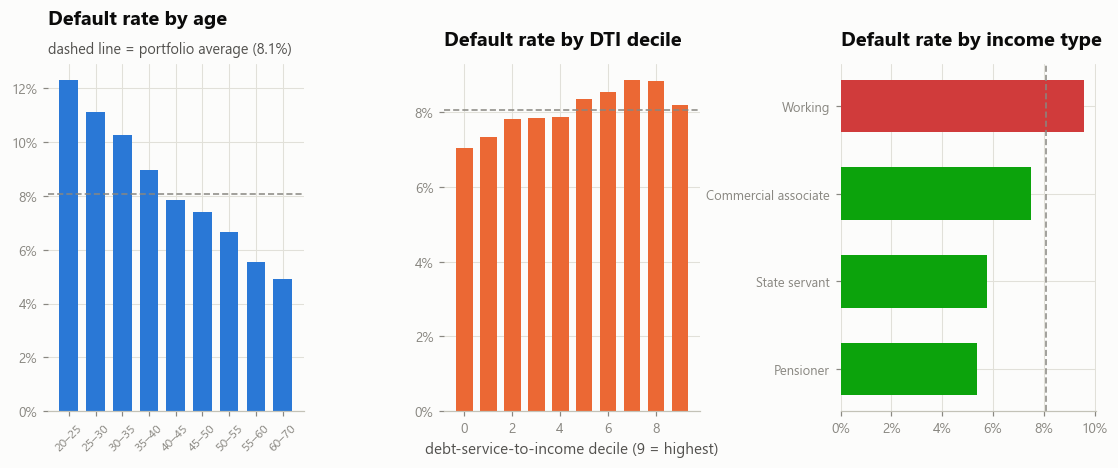

Youngest bucket (20–25): 12.3%   Oldest (60–70): 4.9%
Top DTI decile: 8.2%   Bottom: 7.1%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.3, 4.1), gridspec_kw={"wspace": 0.55})

# default rate by age bucket
age_bucket = pd.cut(app["AGE_YEARS"], bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70])
by_age = app.groupby(age_bucket, observed=True)["TARGET"].agg(["mean", "size"])
ax = axes[0]
ax.bar(range(len(by_age)), by_age["mean"], color=BLUE, width=0.7)
ax.set_xticks(range(len(by_age)))
ax.set_xticklabels([f"{int(i.left)}\u2013{int(i.right)}" for i in by_age.index], fontsize=8, rotation=45)
ax.axhline(rate, color=MUTED, lw=1, ls=(0, (4, 2)))
ax.set_title("Default rate by age")
fmt_pct(ax)

# default rate by DTI decile
dti_dec = pd.qcut(app["DTI"].clip(0, 1), 10, labels=False) if "DTI" in app.columns else None
app_r = features.add_ratio_features(app)
dti_dec = pd.qcut(app_r["DTI"].rank(method="first"), 10, labels=False)
by_dti = app_r.groupby(dti_dec)["TARGET"].mean()
ax = axes[1]
ax.bar(range(10), by_dti.values, color=ORANGE, width=0.7)
ax.axhline(rate, color=MUTED, lw=1, ls=(0, (4, 2)))
ax.set_title("Default rate by DTI decile")
ax.set_xlabel("debt-service-to-income decile (9 = highest)")
fmt_pct(ax)

# default rate by income type (top segments)
by_inc = (app.groupby("NAME_INCOME_TYPE")["TARGET"].agg(["mean", "size"])
          .query("size > 1000").sort_values("mean"))
ax = axes[2]
colors = [GOOD if v < rate else CRITICAL for v in by_inc["mean"]]
ax.barh(range(len(by_inc)), by_inc["mean"], color=colors, height=0.6)
ax.set_yticks(range(len(by_inc))); ax.set_yticklabels(by_inc.index, fontsize=8.5)
ax.axvline(rate, color=MUTED, lw=1, ls=(0, (4, 2)))
ax.set_title("Default rate by income type")
fmt_pct(ax, "x")
subtitle(axes[0], f"dashed line = portfolio average ({rate:.1%})")
save_figure(fig, "eda_segments")
plt.show()

print(f"Youngest bucket (20\u201325): {by_age['mean'].iloc[0]:.1%}   Oldest (60\u201370): {by_age['mean'].iloc[-1]:.1%}")
print(f"Top DTI decile: {by_dti.iloc[9]:.1%}   Bottom: {by_dti.iloc[0]:.1%}")

**Reading the segments (Five Cs in action):** age is a proxy for **Character** maturity — the 20–25 bucket defaults at 12.3%, 2.5× the 60+ rate. Income type is **Conditions** (working applicants riskier than pensioners and state servants). DTI — the classic **Capacity** metric — turns out surprisingly *weak* on its own here: the gradient runs only ~7.1% → 8.8% across deciles. The reason is instructive: `AMT_ANNUITY` is the annuity the lender *already approved*, so underwriting has partially flattened the ratio. Capacity signal survives in the interactions and bureau debt features, which is exactly why notebook 03 engineers them rather than trusting one ratio.

---
## 5. The Bureau: Character Evidence from Other Lenders

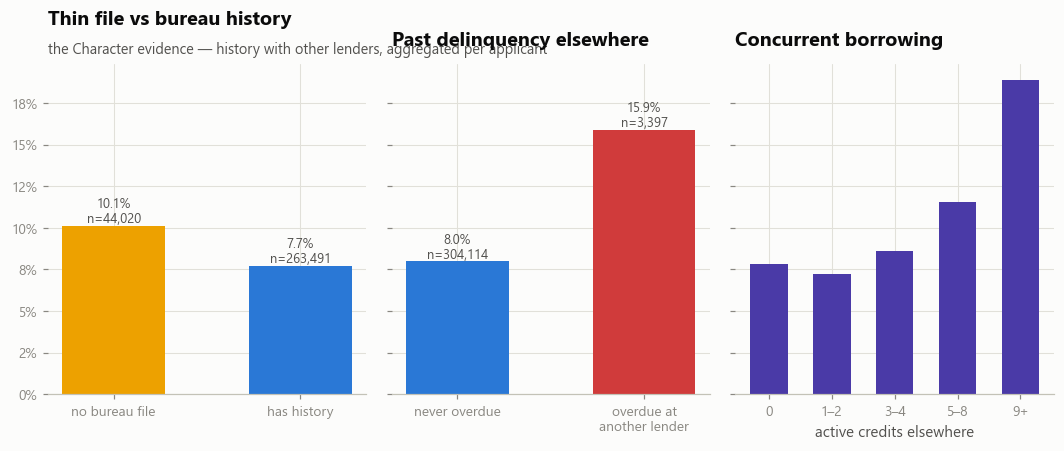

In [8]:
bureau = data.load_bureau()
bagg = features.aggregate_bureau(bureau)
merged = features.merge_bureau(app_r, bagg)

fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.9), sharey=True, gridspec_kw={"wspace": 0.08})

groups = [
    ("HAS_BUREAU_FILE", {0: "no bureau file\n(thin file)", 1: "has bureau\nhistory"}, "Thin file vs history"),
    (None, None, None),  # placeholder replaced below
]

# panel 1: thin file
g = merged.groupby("HAS_BUREAU_FILE")["TARGET"].agg(["mean", "size"])
ax = axes[0]
ax.bar([0, 1], g["mean"], color=[YELLOW, BLUE], width=0.55)
ax.set_xticks([0, 1]); ax.set_xticklabels(["no bureau file", "has history"], fontsize=9)
for i, (m, s) in enumerate(zip(g["mean"], g["size"])):
    ax.text(i, m + 0.002, f"{m:.1%}\nn={s:,}", ha="center", fontsize=8.5, color=INK_2)
ax.set_title("Thin file vs bureau history")
fmt_pct(ax)

# panel 2: ever overdue at another lender
merged["EVER_OVERDUE"] = (merged["BURO_OVERDUE_COUNT"].fillna(0) > 0).astype(int)
g = merged.groupby("EVER_OVERDUE")["TARGET"].agg(["mean", "size"])
ax = axes[1]
ax.bar([0, 1], g["mean"], color=[BLUE, CRITICAL], width=0.55)
ax.set_xticks([0, 1]); ax.set_xticklabels(["never overdue", "overdue at\nanother lender"], fontsize=9)
for i, (m, s) in enumerate(zip(g["mean"], g["size"])):
    ax.text(i, m + 0.002, f"{m:.1%}\nn={s:,}", ha="center", fontsize=8.5, color=INK_2)
ax.set_title("Past delinquency elsewhere")
fmt_pct(ax)

# panel 3: number of active credits
n_act = pd.cut(merged["BURO_ACTIVE_COUNT"].fillna(0), bins=[-1, 0, 2, 4, 8, 100],
               labels=["0", "1\u20132", "3\u20134", "5\u20138", "9+"])
g = merged.groupby(n_act, observed=True)["TARGET"].mean()
ax = axes[2]
ax.bar(range(len(g)), g.values, color=VIOLET, width=0.6)
ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, fontsize=9)
ax.set_xlabel("active credits elsewhere")
ax.set_title("Concurrent borrowing")
fmt_pct(ax)
subtitle(axes[0], "the Character evidence \u2014 history with other lenders, aggregated per applicant")
save_figure(fig, "eda_bureau_signal")
plt.show()

**The bureau earns its 1.7M rows:** past delinquency elsewhere roughly doubles default risk — the single cleanest Character signal in the data, exactly as the Five Cs predict ("the strongest category of features in most credit models"). Concurrent borrowing shows the classic risk U-shape: heavy simultaneous borrowing marks stress.

---
## 6. What Correlates with Default — Honest Effect Sizes

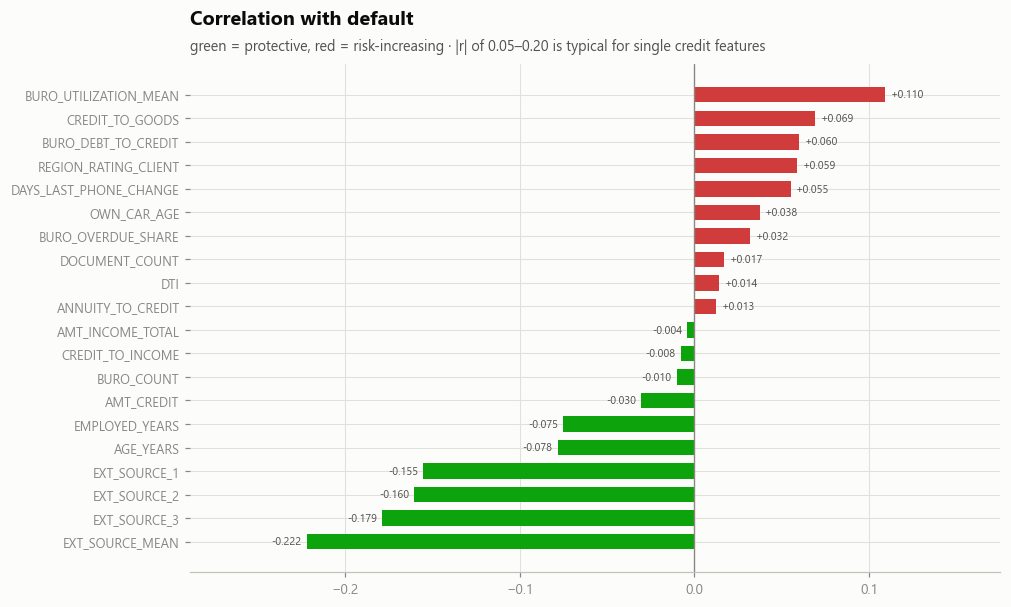

In [9]:
num_cols = ["EXT_SOURCE_MEAN", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
            "AGE_YEARS", "EMPLOYED_YEARS", "DTI", "CREDIT_TO_INCOME", "CREDIT_TO_GOODS",
            "ANNUITY_TO_CREDIT", "AMT_INCOME_TOTAL", "AMT_CREDIT", "DOCUMENT_COUNT",
            "REGION_RATING_CLIENT", "DAYS_LAST_PHONE_CHANGE", "OWN_CAR_AGE",
            "BURO_OVERDUE_SHARE", "BURO_UTILIZATION_MEAN", "BURO_COUNT", "BURO_DEBT_TO_CREDIT"]
corr = (merged[num_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
        .sort_values())

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = [CRITICAL if v > 0 else GOOD for v in corr]
ax.barh(range(len(corr)), corr.values, color=colors, height=0.65)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8.5)
ax.axvline(0, color=MUTED, lw=0.9)
ax.set_title("Correlation with default")
subtitle(ax, "green = protective, red = risk-increasing \u00b7 |r| of 0.05\u20130.20 is typical for single credit features")
for i, v in enumerate(corr.values):
    ax.text(v + (0.003 if v >= 0 else -0.003), i, f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=7, color=INK_2)
ax.set_xlim(corr.min() * 1.3, corr.max() * 1.6)
save_figure(fig, "eda_target_correlations")
plt.show()

---
## 7. Findings → Decisions for Notebooks 02–05

| Finding | Decision it drives |
|---|---|
| 8.07% default rate | Stratified splits; AUROC/Gini/KS + PR metrics; asymmetric cost framing |
| `DAYS_EMPLOYED` sentinel on 18% of rows (pensioners) | NaN + `FLAG_NOT_EMPLOYED`; audit every column for sentinels before modeling |
| Building-info block ~50% missing | Median-impute + missing indicators; don't drop 40+ columns of weak-but-real signal |
| Missingness is informative (EXT_SOURCE_1) | Keep indicator flags alongside imputations |
| EXT_SOURCE trio = strongest predictors | Engineer mean/min/count combinations (notebook 03) |
| Bureau delinquency ≈ 2× risk | Aggregate all 1.7M bureau rows into per-applicant Character features |
| Segment risk varies 2–3× (age, income type, DTI) | Segment-level performance review in the stability report (notebook 05) |

**Next:** notebook `02_preprocessing.ipynb` — the cleaning pipeline applied split-safe: stratified 70/15/15, imputation fit on train only, every transform reproducible from `src/`.